
### STAGE 5: Feature Engineering & Selection


#### 5.1 Importing Required Libraries

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import (train_test_split, cross_val_score,
                                      StratifiedKFold, GridSearchCV)
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.decomposition import PCA

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

print('All libraries imported successfully.')


All libraries imported successfully.


#### 5.2 Load the Dataset

In [5]:
df = pd.read_csv('Crop_recommendation.csv')

print(f'Shape         : {df.shape}')
print(f'Unique crops  : {df["label"].nunique()}')
print(f'Samples/crop  : {df["label"].value_counts().unique()} (perfectly balanced)')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Duplicates    : {df.duplicated().sum()}')
df.describe().round(2)


Shape         : (2200, 8)
Unique crops  : 22
Samples/crop  : [100] (perfectly balanced)
Missing values: 0
Duplicates    : 0


,N,P,K,temperature,humidity,ph,rainfall
count,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00,2200.00
mean,50.55,53.36,48.15,25.62,71.48,6.47,103.46
std,36.92,32.99,50.65,5.06,22.26,0.77,54.96
min,0.00,5.00,5.00,8.83,14.26,3.50,20.21
25%,21.00,28.00,20.00,22.77,60.26,5.97,64.55
50%,37.00,51.00,32.00,25.60,80.47,6.43,94.87
75%,84.25,68.00,49.00,28.56,89.95,6.92,124.27
max,140.00,145.00,205.00,43.68,99.98,9.94,298.56


#### 5.3 Feature Importance Analysis

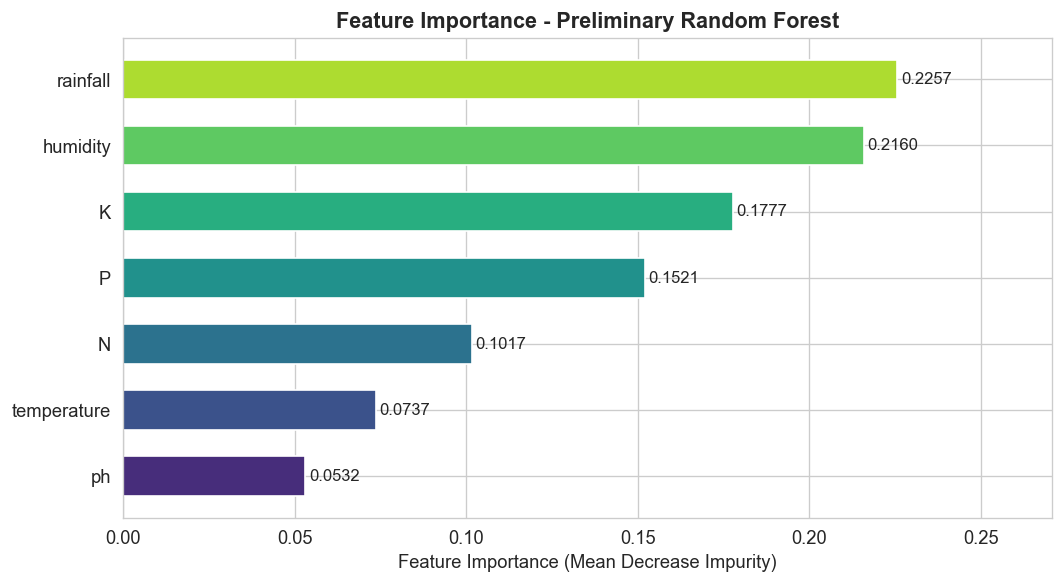

Ranking (highest to lowest):
  rainfall       : 0.2257
  humidity       : 0.2160
  K              : 0.1777
  P              : 0.1521
  N              : 0.1017
  temperature    : 0.0737
  ph             : 0.0532


In [7]:
le = LabelEncoder()
df['label_enc'] = le.fit_transform(df['label'])
feature_cols = [col for col in df.columns if col not in ['label', 'label_enc']]
X_all = df[feature_cols].values
y_all = df['label_enc'].values
classes = le.classes_

rf_prelim = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_prelim.fit(X_all, y_all)

importances = rf_prelim.feature_importances_
idx = np.argsort(importances)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette('viridis', len(feature_cols))
bars = ax.barh([feature_cols[i] for i in idx], importances[idx],
               color=colors, edgecolor='white', height=0.6)
for bar, val in zip(bars, importances[idx]):
    ax.text(val+0.001, bar.get_y()+bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=10)
ax.set_xlabel('Feature Importance (Mean Decrease Impurity)')
ax.set_title('Feature Importance - Preliminary Random Forest',
             fontsize=13, fontweight='bold')
ax.set_xlim(0, importances.max()*1.2)
plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight')
plt.show()

print('Ranking (highest to lowest):')
for i in idx[::-1]:
    print(f'  {feature_cols[i]:15s}: {importances[i]:.4f}')


#### 5.4 Dimensionality Reduction

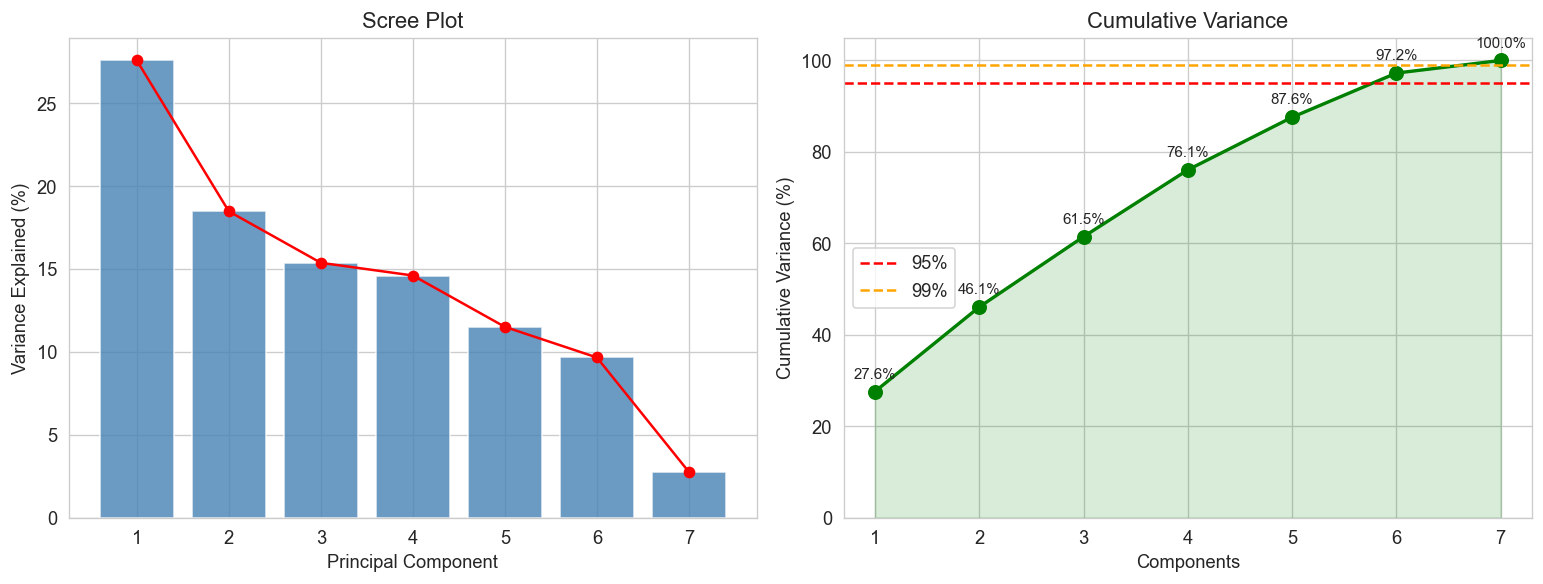

Decision: All 7 features needed for 99% variance. No dimensionality reduction applied.
Reducing features would hurt interpretability without meaningful computational gain.


In [8]:
X_scaled_pca = StandardScaler().fit_transform(X_all)
pca = PCA().fit(X_scaled_pca)
cum_var = np.cumsum(pca.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].bar(range(1,8), pca.explained_variance_ratio_*100,
            color='steelblue', edgecolor='white', alpha=0.8)
axes[0].plot(range(1,8), pca.explained_variance_ratio_*100, 'ro-', markersize=6)
axes[0].set(xlabel='Principal Component', ylabel='Variance Explained (%)',
            title='Scree Plot', xticks=range(1,8))

axes[1].plot(range(1,8), cum_var*100, 'go-', markersize=8, linewidth=2)
axes[1].axhline(95, color='red',    linestyle='--', label='95%')
axes[1].axhline(99, color='orange', linestyle='--', label='99%')
axes[1].fill_between(range(1,8), cum_var*100, alpha=0.15, color='green')
for i, v in enumerate(cum_var*100):
    axes[1].annotate(f'{v:.1f}%', (i+1, v), xytext=(0,8),
                     textcoords='offset points', ha='center', fontsize=9)
axes[1].set(xlabel='Components', ylabel='Cumulative Variance (%)',
            title='Cumulative Variance', xticks=range(1,8), ylim=(0,105))
axes[1].legend()
plt.tight_layout()
plt.savefig('pca_analysis.png', bbox_inches='tight')
plt.show()

print('Decision: All 7 features needed for 99% variance. No dimensionality reduction applied.')
print('Reducing features would hurt interpretability without meaningful computational gain.')


#### 5.5 Final Feature Selection and Data Preparation

In [9]:
FEATURES = ['N', 'P', 'K', 'temperature', 'humidity', 'ph', 'rainfall']

X = df[FEATURES].values
y = df['label_enc'].values

# Stratified 80/20 split -- ensures all 22 crops appear in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# StandardScaler -- fit ONLY on training data to prevent data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Data preparation complete.')
print(f'  Train : {X_train.shape[0]} samples')
print(f'  Test  : {X_test.shape[0]} samples')
print(f'  Crops : {len(classes)}')
print()
# Verify class balance in split
train_counts = pd.Series(y_train).value_counts()
print(f'  Samples per crop in train set: min={train_counts.min()}, max={train_counts.max()}')
print(f'  Samples per crop in test  set: ', end='')
test_counts = pd.Series(y_test).value_counts()
print(f'min={test_counts.min()}, max={test_counts.max()}')


Data preparation complete.
  Train : 1760 samples
  Test  : 440 samples
  Crops : 22

  Samples per crop in train set: min=80, max=80
  Samples per crop in test  set: min=20, max=20
